In [7]:
import numpy as np
import matplotlib.pyplot as plt
from file_management import load_arrs
import os

/tmp/ipykernel_2571453/3307593119.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[2].scatter(phi_float, np.std(te) / np.mean(te), c=c)
/tmp/ipykernel_2571453/3307593119.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[3].scatter(phi_float, 2 * np.mean(data['ke'] + data['ke_r']) / (3 * 100), c=c)


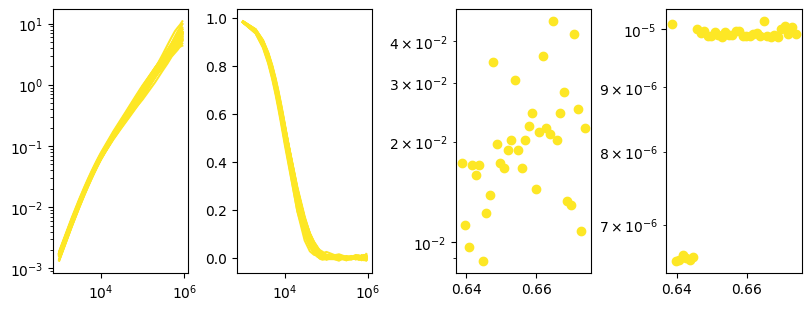

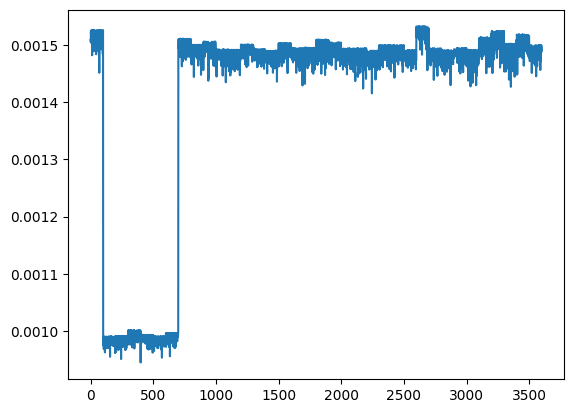

In [11]:
root = '/home/mmccraw/dev/data/26-01-01/grant/dp-fragility-2/help/mu-0.01-alpha-1.2-nv-20/'

norm = plt.Normalize(0.6, 0.6005)
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 4, figsize=(8, 3), constrained_layout=True)

phis = []
kes = []

for phi in os.listdir(root):
    phi_float = float(phi.split('-')[-1])
    c = cmap(norm(phi_float))
    try:
        data = load_arrs(
            os.path.join(root, phi, 'traj', 'data.h5')
        )
    except:
        continue
    ax[0].plot(data['t_dimless'], data['msd'], c=c)
    ax[1].plot(data['t_dimless'], data['isf'], c=c)
    te = data['pe'] + data['ke']
    kes.append(data['ke'] + data['ke_r'])
    phis.append(phi_float)
    ax[2].scatter(phi_float, np.std(te) / np.mean(te), c=c)
    ax[3].scatter(phi_float, 2 * np.mean(data['ke'] + data['ke_r']) / (3 * 100), c=c)
for a in ax[:2]:
    a.set_xscale('log')
ax[0].set_yscale('log')
ax[2].set_yscale('log')
ax[3].set_yscale('log')
plt.show()

plt.plot(np.concatenate([kes[i] for i in np.argsort(phis)]))